In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [3]:
rho = 1.225

number_chordwise_panels = 8
number_spanwise_nodes = 16
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [4]:
# Define the range of velocity and angle of attack
velocity_range = np.arange(10, 41, 1)  # 10 to 40 m/s
aoa_range = np.arange(0.5, 10.5, 0.5)  # 0.5 to 10 degrees

In [ ]:
length = 1.2
width = 0.06
height = 0.004
c_ref= 0.2
massperunit = 1.8
massweight = 0.1

def new_update_mass_stiff(self):
            import sharpy.utils.algebra as algebra

            #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
            #structural properties appropriately to achieve flutter, (as lift forces are proportional
            #to the wing area)
            E = 69e9  # Young's modulus in Pascals (Pa)
            G = 26e9  # Shear modulus in Pascals (Pa)
            rho = 2700

            # Cross-sectional properties
            A = width * height  # Area in m²
            Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
            Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
            J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

            # Rigidity calculations
            EA = E * A
            GA = G * A
            GJ = G * J
            EIy = E * Iy
            EIz = E * Iz

            ea, ga = EA, GA
            gj = GJ
            eiy = EIy
            eiz = EIz
            base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
            self.stiffness = np.zeros((1, 6, 6))
            self.stiffness[0] = base_stiffness
            
            m_unit = massperunit
            j_tors = (Iy+Iz)*rho
            pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
            m_chi_cg = algebra.skew(m_unit * pos_cg_b)
            self.mass = np.zeros((1, 6, 6))
            self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                            j_tors, .1 * j_tors, .9 * j_tors])

            self.mass[0, :3, 3:] = m_chi_cg
            self.mass[0, 3:, :3] = -m_chi_cg

            self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
            self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

            n_lumped_mass = 2
            self.lumped_mass = np.zeros((n_lumped_mass))
            self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
            self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
            self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

            #positive y is towards back
            self.lumped_mass[0] = massweight
            self.lumped_mass_position[0] = np.array([0, 0.5, 0])
            self.lumped_mass_nodes[0] = self.N//2
            self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

            self.lumped_mass[1] = massweight
            self.lumped_mass_position[1] = np.array([0, 0.5, 0])
            self.lumped_mass_nodes[1] = self.N//2+1
            self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

            self.main_ea = 0.33
            self.main_cg = 0.43

: 

In [ ]:
for v in velocity_range:
    for aoa in aoa_range:
        case_name = f"Case_u{v}_aoa{aoa}"
        route_test_dir = os.path.abspath('')

        pazy_altered = wings.PazyControlSurface(
            M = number_chordwise_panels,
            N = number_spanwise_nodes,
            Mstar_fact=10,
            u_inf=v,
            alpha=aoa,
            cs_deflection=[0,0],
            n_control_surfaces=2,
            rho=rho,
            tip_rod=False,
            b_ref=2.*length,
            main_chord=c_ref,
            pct_flap=0.2,
            aspect_ratio=2*length/c_ref,
            n_surfaces=2,
            physical_time=2,
            route = cases_folder + '/' + case_name,
            case_name=case_name,
            #physical_time = simulation_time,
        )

        pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

        pazy_altered.clean_test_files()
        pazy_altered.update_derived_params()
        pazy_altered.set_default_config_dict()

        pazy_altered.generate_aero_file()
        pazy_altered.generate_fem_file()

        rom_settings = dict()
        rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
        rom_settings['r'] = 6  # Krylov subspace order
        frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
        frequency_continuous_w = 2 * v * frequency_continuous_k / c_ref
        rom_settings['frequency'] = frequency_continuous_w

        pazy_altered.config['SHARPy'] = {
            'flow':
                ['BeamLoader', 'AerogridLoader',
                'StaticCoupled',
                'AerogridPlot',
                'BeamPlot',
                'Modal',
                'LinearAssembler',
                'AsymptoticStability',
                ],
            'case': pazy_altered.case_name, 'route': pazy_altered.route,
            'write_screen': 'off', 'write_log': 'off',    # Change to 'on' as neded.
            'log_folder': route_test_dir + '/output/',
            'log_file': pazy_altered.case_name + '.log'
        }

        pazy_altered.config['BeamLoader'] = {
            'unsteady': 'off',
            'orientation': pazy_altered.quat}

        pazy_altered.config['AerogridLoader'] = {
            'unsteady': 'off',
            'aligned_grid': 'on',
            'mstar': pazy_altered.Mstar_fact * pazy_altered.M,
            'freestream_dir': pazy_altered.u_inf_direction,
            'wake_shape_generator': 'StraightWake',
            'wake_shape_generator_input': {'u_inf': pazy_altered.u_inf,
                                            'u_inf_direction': pazy_altered.u_inf_direction,
                                            'dt': pazy_altered.dt}}

        pazy_altered.config['StaticCoupled'] = {
            'print_info': 'off',
            'max_iter': 200,
            'n_load_steps': 1,
            'tolerance': 1e-10,
            'relaxation_factor': 0.,
            'aero_solver': 'StaticUvlm',
            'aero_solver_settings': {
                'rho': pazy_altered.rho,
                'print_info': 'off',
                'horseshoe': 'off',
                'num_cores': 4,
                'n_rollup': 0,
                'rollup_dt': pazy_altered.dt,
                'rollup_aic_refresh': 1,
                'rollup_tolerance': 1e-4,
                'velocity_field_generator': 'SteadyVelocityField',
                'velocity_field_input': {
                    'u_inf': pazy_altered.u_inf,
                    'u_inf_direction': pazy_altered.u_inf_direction}},
            'structural_solver': 'NonLinearStatic',
            'structural_solver_settings': {'print_info': 'off',
                                        'max_iterations': 150,
                                        'num_load_steps': 4,
                                        'delta_curved': 1e-1,
                                        'min_delta': 1e-10,
                                        'gravity_on': 'on',
                                        'gravity': 9.81}}

        pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                                    'include_applied_forces': 'on',
                                    'minus_m_star': 0}

        pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                                'include_applied_forces': 'on'}

        pazy_altered.config['Modal'] = {'NumLambda': 20,
                            'rigid_body_modes': 'off',
                            'print_matrices': 'off', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                            'rigid_modes_cg': 'off',
                            'continuous_eigenvalues': 'off',
                            'dt': 0,
                            'plot_eigenvalues': False,
                            'max_rotation_deg': 15.,
                            'max_displacement': 0.15,
                            'write_modes_vtk': True,
                            'use_undamped_modes': True}

        pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                        'linear_system_settings': {
                                            'beam_settings': {'modal_projection': 'on',
                                                            'inout_coords': 'modes',
                                                            'discrete_time': 'on',
                                                            'newmark_damp': 0.5e-4,
                                                            'discr_method': 'newmark',
                                                            'dt': pazy_altered.dt,
                                                            'proj_modes': 'undamped',
                                                            'use_euler': 'off',
                                                            'num_modes': 20,
                                                            'print_info': 'off',
                                                            'gravity': 'on',
                                                            'remove_sym_modes': 'on',
                                                            'remove_dofs': []},
                                            'aero_settings': {'dt': pazy_altered.dt,
                                                            'ScalingDict': {'length': 0.5 * pazy_altered.c_ref,
                                                                            'speed': v,
                                                                            'density': rho},
                                                            'integr_order': 2,
                                                            'density': pazy_altered.rho,
                                                            'remove_predictor': 'on',
                                                            'use_sparse': 'on',
                                                            'remove_inputs': ['u_gust'],
                                                            'rom_method': ['Krylov'],
                                                            'rom_method_settings': {'Krylov': rom_settings}},
                                            }}

        pazy_altered.config['AsymptoticStability'] = {'print_info': False,
                                            'velocity_analysis': [10, 60, 81],
                                        'modes_to_plot': []}
                                            

        pazy_altered.config.write()
        
        try:
                sharpy_output = sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])
        except Exception as e:
                print(f"SHARPy crashed for case {case_name}: {e}")
                continue

        except Exception as e:
            print(f"Error setting up case {case_name}: {e}")
            continue

fatal: not a git repository (or any of the parent directories): .git


 computing lumped masses
 computing lumped masses


/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning: Reduced Order Model Unstable
  warn.warn('Reduced Order Model Unstable')
fatal: not a git repository (or any of the parent directories): .git


 computing lumped masses
 computing lumped masses


/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
fatal: not a git repository (or any of the parent directories): .git


...

/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning: Reduced Order Model Unstable
  warn.warn('Reduced Order Model Unstable')
fatal: not a git repository (or any of the parent directories): .git


 computing lumped masses
 computing lumped masses


/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning: Reduced Order Model Unstable
  warn.warn('Reduced Order Model Unstable')
fatal: not a git repository (or any of the parent directories): .git


 computing lumped masses
 computing lumped masses


/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning: Reduced Order Model Unstable
  warn.warn('Reduced Order Model Unstable')
fatal: not a git repository (or any of the parent directories): .git
STOP Static equations did not converge (17235)


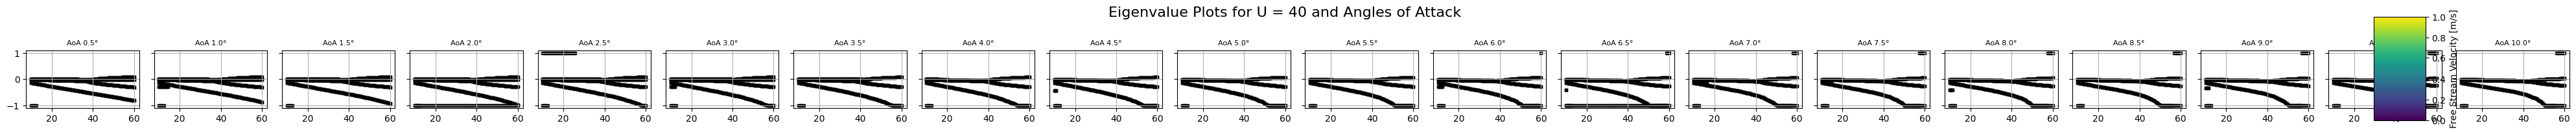

In [11]:
# Grid size
num_rows = 1
num_cols = len(aoa_range)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2), sharex=True, sharey=True)
fig.suptitle(f"Eigenvalue Plots for U = {v} and Angles of Attack", fontsize=16)

v = 10
for j, alpha_deg in enumerate(aoa_range):
    case_name = f"Case_u{v}_aoa{alpha_deg}"
    
    # Load the stability analysis data for this case
    file_name = f'./output/{case_name}/stability/velocity_analysis_min0100_max0600_nvel0081.dat'
    try:
        velocity_analysis = np.loadtxt(file_name)
        u_inf = velocity_analysis[:, 0]
        eigs_r = velocity_analysis[:, 1]
        eigs_i = velocity_analysis[:, 2]
        natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
        damping_ratio = eigs_r / natural_frequency
    except Exception as e:
        print(f"Error loading file for AoA={alpha_deg}: {e}")
        continue
    
    ax = axes[j] if num_cols > 1 else axes  # Handle cases where aoa_range has only one element
    cond = (eigs_r > -25) & (eigs_r < 10) & (natural_frequency < 100)  # Filter unwanted eigenvalues
    scatter = ax.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)
    ax.set_title(f"AoA {alpha_deg}°", fontsize=8)
    ax.grid(True)

# Adjust layout and show the plot
plt.tight_layout(rect=[0, 0, 1, 0.97])
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
fig.colorbar(scatter, cax=cbar_ax, label='Free Stream Velocity [m/s]')
plt.show()